<a href="https://colab.research.google.com/github/ronald154/DocumentationPractice/blob/master/ujian_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UAS Kecerdasan Buatan 2026
Multi Layer Perceptron untuk Klasifikasi Fashion MNIST

Nama:
NIM:

## Petunjuk

1. Setiap tugas berisi contoh yang bisa dijalankan, lalu perintah modifikasi.
2. Gunakan NIM anda sebagai seed.
3. Commit setelah setiap tugas. Minimal 5 commit.
4. Sertakan NIM di setiap output.

## Setup

Jalankan sel berikut untuk import library dan load dataset Fashion MNIST.

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import random

nim = 202410370110154  # Ganti dengan NIM anda
seed = nim % (2**32)
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
print(f"NIM: {nim}  Seed: {seed}")

NIM: 202410370110154  Seed: 1446351562


In [14]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

torch.manual_seed(nim)
train_subset, val_subset = random_split(train_data, [50000, 10000])

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

print(f"Train: {len(train_subset)}, Val: {len(val_subset)}, Test: {len(test_data)}")
print(f"Kelas: {train_data.classes}")

Train: 50000, Val: 10000, Test: 10000
Kelas: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## Tugas 1: Visualisasi Data (10%)

Contoh berikut menampilkan 4 gambar pertama dari dataset. Modifikasi agar menampilkan 10 gambar (satu per kelas) dalam grid 2x5 dengan judul nama kelas masing-masing.

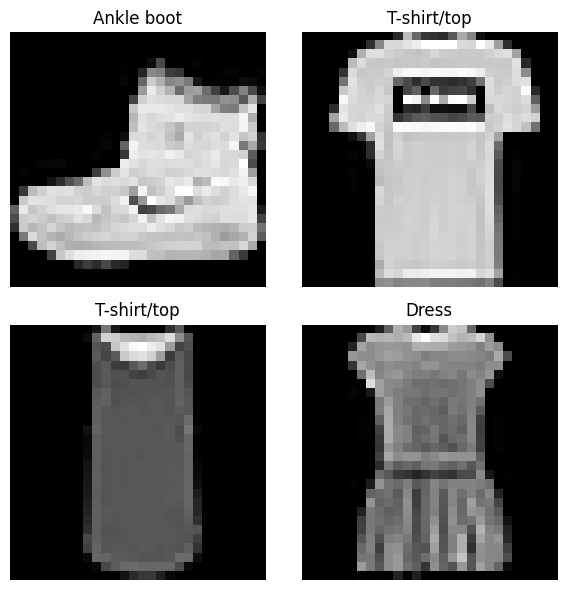

In [15]:
# Contoh: menampilkan 4 gambar dalam grid 2x2
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
for i in range(4):
    img, label = train_data[i]
    ax = axes[i//2, i%2]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(train_data.classes[label])
    ax.axis('off')
plt.tight_layout()
plt.show()

Petunjuk:
- Gunakan `plt.subplots(2, 5, figsize=(12, 6))`
- Cari index gambar pertama setiap kelas: `(train_data.targets == i).nonzero(as_tuple=True)[0][0]`
- Letakkan gambar di `axes[i//5, i%5]`

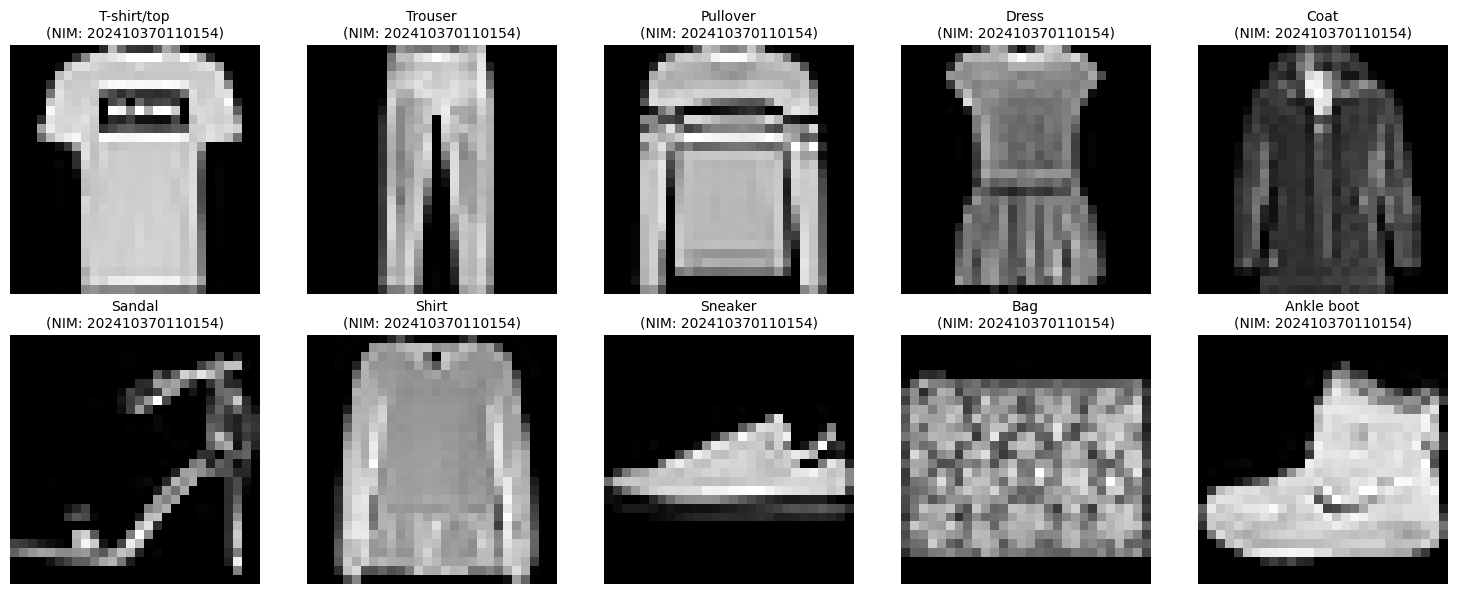

In [16]:
# Tulis kode Tugas 1 di sini (10 gambar, grid 2x5)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i in range(10):
    # Cari index gambar pertama untuk setiap kelas
    idx = (train_data.targets == i).nonzero(as_tuple=True)[0][0].item()
    img, label = train_data[idx]

    # Tentukan posisi grid 2x5
    ax = axes[i // 5, i % 5]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"{train_data.classes[label]}\n(NIM: {nim})", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Tugas 2: Multi Layer Perceptron (25%)

Contoh berikut adalah MLP dengan 1 hidden layer (256 neuron) dan training yang hanya mencatat loss train. Modifikasi class MLP agar memiliki **2 hidden layer** (256 dan 128 neuron). Pada training, catat juga loss dan accuracy untuk data validation. Plot hasilnya dalam 2 subplot (loss dan accuracy) yang masing-masing membandingkan train vs validation.

In [ ]:
# Contoh: MLP dengan 1 hidden layer
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

model = MLP()
print(model)
print(f"Parameter: {sum(p.numel() for p in model.parameters())}")

In [ ]:
# Contoh: training dan plot loss (hanya train)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_losses = []

for epoch in range(10):
    model.train()
    running_loss = 0
    for X, y in train_loader:
        optimizer.zero_grad()
        output = model(X)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_losses.append(running_loss / len(train_loader))
    print(f'Epoch {epoch+1}: loss = {train_losses[-1]:.4f}')

plt.plot(train_losses, label='Train')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Petunjuk:
- Tambah 1 hidden layer lagi di nn.Sequential: `nn.Linear(256, 128)` dan `nn.ReLU()`, lalu output `nn.Linear(128, 10)`
- Di dalam loop epoch, buat blok validation (mirip train tapi tanpa backward, gunakan `torch.no_grad()`)
- Hitung accuracy: `correct / total * 100` untuk train dan validation
- Plot dengan `plt.subplots(1, 2, figsize=(12, 4))`

Epoch  1 | Train Loss: 0.5189 Val Loss: 0.4193 | Train Acc: 81.01% Val Acc: 84.70%
Epoch  2 | Train Loss: 0.3831 Val Loss: 0.3615 | Train Acc: 85.96% Val Acc: 86.76%
Epoch  3 | Train Loss: 0.3428 Val Loss: 0.3364 | Train Acc: 87.27% Val Acc: 87.53%
Epoch  4 | Train Loss: 0.3167 Val Loss: 0.3421 | Train Acc: 88.26% Val Acc: 87.62%
Epoch  5 | Train Loss: 0.2975 Val Loss: 0.3529 | Train Acc: 89.03% Val Acc: 87.12%
Epoch  6 | Train Loss: 0.2787 Val Loss: 0.3274 | Train Acc: 89.59% Val Acc: 88.40%
Epoch  7 | Train Loss: 0.2638 Val Loss: 0.3152 | Train Acc: 90.20% Val Acc: 88.58%
Epoch  8 | Train Loss: 0.2492 Val Loss: 0.3140 | Train Acc: 90.63% Val Acc: 88.94%
Epoch  9 | Train Loss: 0.2390 Val Loss: 0.3210 | Train Acc: 91.06% Val Acc: 88.72%
Epoch 10 | Train Loss: 0.2287 Val Loss: 0.3534 | Train Acc: 91.38% Val Acc: 87.71%
Epoch 11 | Train Loss: 0.2167 Val Loss: 0.3159 | Train Acc: 91.78% Val Acc: 89.27%
Epoch 12 | Train Loss: 0.2052 Val Loss: 0.3382 | Train Acc: 92.20% Val Acc: 88.33%

NIM

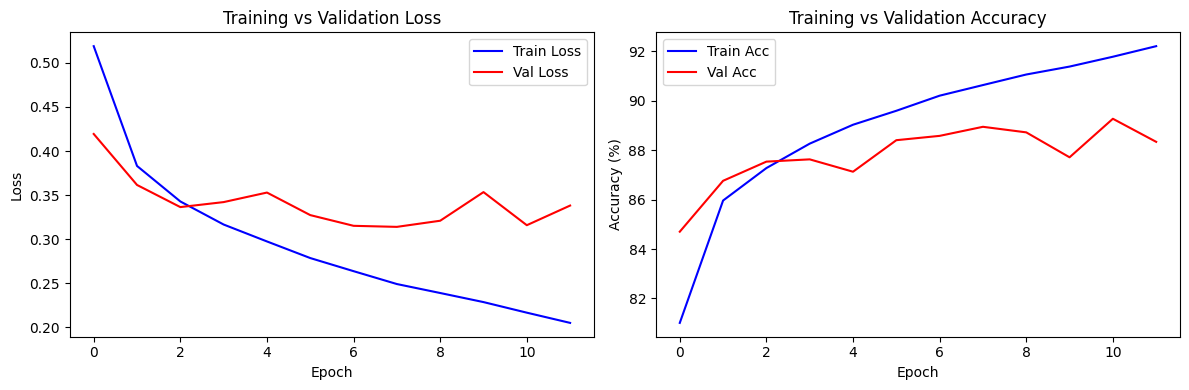

In [10]:
# 1. Tambahkan import library grafik terlebih dahulu agar tidak NameError
import matplotlib.pyplot as plt

# Definisikan Arsitektur MLP dengan 2 Hidden Layer (256 dan 128)
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256),    # Hidden Layer 1
            nn.ReLU(),
            nn.Linear(256, 128),    # Hidden Layer 2
            nn.ReLU(),
            nn.Linear(128, 10)      # Output Layer
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)   # Flatten gambar 28x28 jadi 784
        return self.net(x)

# Inisialisasi Model sesuai seed NIM kamu
torch.manual_seed(seed)
model = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# List untuk mencatat history performa
train_losses, val_losses = [], []
train_accs, val_accs = [], []

# 2. Proses Training dan Validation selama 12 Epoch
for epoch in range(12):
    # --- PHASE TRAINING ---
    model.train()
    t_loss, t_correct, t_total = 0, 0, 0
    for X, y in train_loader:
        optimizer.zero_grad()
        output = model(X)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

        t_loss += loss.item()
        _, predicted = torch.max(output.data, 1)
        t_total += y.size(0)
        t_correct += (predicted == y).sum().item()

    # --- PHASE VALIDATION ---
    model.eval()
    v_loss, v_correct, v_total = 0, 0, 0
    with torch.no_grad():
        for X, y in val_loader:
            output = model(X)
            loss = criterion(output, y)
            v_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            v_total += y.size(0)
            v_correct += (predicted == y).sum().item()

    # Simpan hasil per epoch ke dalam list
    train_losses.append(t_loss / len(train_loader))
    val_losses.append(v_loss / len(val_loader))
    train_accs.append(100.0 * t_correct / t_total)
    val_accs.append(100.0 * v_correct / v_total)

    print(f'Epoch {epoch+1:2d} | Train Loss: {train_losses[-1]:.4f} Val Loss: {val_losses[-1]:.4f} | '
          f'Train Acc: {train_accs[-1]:.2f}% Val Acc: {val_accs[-1]:.2f}%')

# 3. Visualisasi Hasil (Loss dan Accuracy) menggunakan plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
print(f"\nNIM: {nim}")

# Plot Loss
ax1.plot(train_losses, label='Train Loss', color='blue')
ax1.plot(val_losses, label='Val Loss', color='red')
ax1.set_title('Training vs Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# Plot Accuracy
ax2.plot(train_accs, label='Train Acc', color='blue')
ax2.plot(val_accs, label='Val Acc', color='red')
ax2.set_title('Training vs Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()

plt.tight_layout()
plt.show()

## Tugas 3: Eksperimen Arsitektur (25%)

Contoh berikut adalah fungsi train_model dan 1 konfigurasi MLP. Buat **1 konfigurasi tambahan** (beda jumlah layer atau neuron). Bandingkan validation accuracy keduanya dalam satu plot.

In [ ]:
# Contoh: fungsi training dan 1 konfigurasi MLP
def train_model(model, loader):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    accs = []
    for epoch in range(8):
        model.train()
        correct = total = 0
        for X, y in loader:
            optimizer.zero_grad()
            output = model(X)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            _, pred = output.max(1)
            total += y.size(0)
            correct += pred.eq(y).sum().item()
        accs.append(100.0 * correct / total)
    return accs

class MLP1(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

model_a = MLP1()
acc_a = train_model(model_a, train_loader)
print(f"MLP 1 layer (128): akurasi = {acc_a[-1]:.2f}%")

Petunjuk:
- Buat class MLP2 dengan arsitektur berbeda
- Gunakan train_model() untuk melatih
- Plot accuracy kedua model dalam satu grafik

In [ ]:
# Tulis kode eksperimen di sini: 1 konfigurasi tambahan

# TODO: buat class MLP2 dengan arsitektur berbeda (contoh: 3 hidden layer, atau neuron lebih banyak/lebih sedikit)
class MLP2(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: tentukan arsitektur sendiri
        self.net = nn.Sequential()

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

model_b = MLP2()
print(model_b)
print(f"Parameter MLP2: {sum(p.numel() for p in model_b.parameters())}")

# TODO: latih model_b menggunakan train_model()
# acc_b = train_model(model_b, train_loader)
# print(f"Akurasi MLP2: {acc_b[-1]:.2f}%")

# TODO: plot perbandingan akurasi acc_a dan acc_b dalam satu grafik

## Tugas 4: Evaluasi Model (20%)

Pilih model terbaik dari Tugas 3. Contoh berikut menghitung accuracy pada data test. Lengkapi dengan confusion matrix (heatmap) dan classification report (precision, recall, F1-score per kelas).

In [ ]:
# Contoh: evaluasi accuracy (gunakan model sederhana sebagai demo)
class ContohModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(784, 10))
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

contoh_model = ContohModel()
contoh_model.eval()
correct = total = 0
with torch.no_grad():
    for X, y in test_loader:
        output = contoh_model(X)
        _, pred = output.max(1)
        total += y.size(0)
        correct += pred.eq(y).sum().item()

print(f"Test accuracy (contoh): {100.0 * correct / total:.2f}%")

Petunjuk:
- Gunakan `confusion_matrix(all_labels, all_preds)` dari sklearn
- Tampilkan dengan `sns.heatmap(..., annot=True, fmt='d')`
- Gunakan `classification_report(..., target_names=train_data.classes)`

In [ ]:
# Tulis ulang kode evaluasi di sini (accuracy + confusion matrix + classification report)

# TODO: pilih model terbaik dari Tugas 3 (model_a atau model_b)
# best_model = ...

best_model.eval()
all_preds = []
all_labels = []
correct = 0
total = 0

with torch.no_grad():
    for X, y in test_loader:
        output = best_model(X)
        _, pred = output.max(1)
        total += y.size(0)
        correct += pred.eq(y).sum().item()
        # TODO: kumpulkan semua prediksi (all_preds) dan label asli (all_labels)
        pass

accuracy = 100.0 * correct / total
print(f"Test accuracy: {accuracy:.2f}%")

# TODO: hitung confusion matrix dengan sklearn dan tampilkan sebagai heatmap pakai seaborn

# TODO: tampilkan classification report dengan sklearn

In [ ]:
# Verifikasi
print(f"NIM: {nim}")
print(f"Test accuracy: {accuracy:.2f}%")
print(f"Parameter model: {sum(p.numel() for p in best_model.parameters())}")

## Tugas 5: Analisis (20%)

Jawab pertanyaan berikut pada sel di bawah. Jawaban harus spesifik merujuk pada output yang anda peroleh.

1. Lihat grafik loss Tugas 2. Pada epoch berapa validation loss mulai naik atau berhenti turun? Apa artinya?

2. Bandingkan accuracy kedua model di Tugas 3. Model mana yang lebih baik? Mengapa jumlah layer/neuron mempengaruhi hasil?

3. Dari confusion matrix Tugas 4, sebutkan 2 kelas yang paling sering salah prediksi dan berapa jumlahnya. Jelaskan kemiripan visualnya.

4. NIM digunakan sebagai seed. Bagian mana dari eksperimen yang terpengaruh seed? Apakah hasil anda akan berbeda dengan mahasiswa lain? Jelaskan.

### Jawaban Analisis

1.


2.


3.


4.